# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 7 columns: commit, overall_score, correctness, helpfulness, tool_usage, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["overall_score"] = pd.to_numeric(df["overall_score"], errors="coerce")
df["correctness"] = pd.to_numeric(df["correctness"], errors="coerce")
df["helpfulness"] = pd.to_numeric(df["helpfulness"], errors="coerce")
df["tool_usage"] = pd.to_numeric(df["tool_usage"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 31
Columns: ['commit', 'overall_score', 'correctness', 'helpfulness', 'tool_usage', 'status', 'description']


,commit,overall_score,correctness,helpfulness,tool_usage,status,description
0,a5c97f3,0.700000,0.30,1.0,0.80,KEEP,baseline
1,58e8376,0.733333,0.40,1.0,0.80,KEEP,improved system prompt with explicit tool inst...
2,10d11e8,0.683333,0.30,1.0,0.75,DISCARD,added response format instructions (regression)
3,7a23687,0.383333,0.10,0.8,0.25,DISCARD,switched to Qwen2.5-3B (major regression)
4,73cf255,0.700000,0.35,1.0,0.75,DISCARD,temperature=0.1 (slight regression)
5,e556f2a,0.716667,0.40,1.0,0.75,DISCARD,detailed tool descriptions (tool usage dropped)
6,e4557e8,0.733333,0.40,1.0,0.80,KEEP,added few-shot examples (tied best)
7,443c2ca,0.733333,0.40,1.0,0.80,KEEP,increased max_tokens to 1024 (tied best)
8,85e7011,0.000000,0.00,0.0,0.00,CRASH,8B model too slow (timeout)
9,1f5aac6,0.183333,0.15,0.2,0.20,DISCARD,Phi-4-mini model performed poorly


In [6]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
KEEP       16
DISCARD    14
CRASH       1

Keep rate: 16/30 = 53.3%


In [7]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    score = row["overall_score"]
    desc = row["description"]
    print(f"  Exp {i+1:2d}: score={score:.6f}  correctness={row['correctness']:.2f}  tool_usage={row['tool_usage']:.2f}  {desc}")

KEPT experiments (16 total):

  Exp  1: score=0.700000  correctness=0.30  tool_usage=0.80  baseline
  Exp  2: score=0.733333  correctness=0.40  tool_usage=0.80  improved system prompt with explicit tool instructions
  Exp  7: score=0.733333  correctness=0.40  tool_usage=0.80  added few-shot examples (tied best)
  Exp  8: score=0.733333  correctness=0.40  tool_usage=0.80  increased max_tokens to 1024 (tied best)
  Exp 11: score=0.750000  correctness=0.45  tool_usage=0.80  added verification step (NEW BEST)
  Exp 12: score=0.750000  correctness=0.45  tool_usage=0.80  strengthened verification instruction (tied best)
  Exp 13: score=0.783333  correctness=0.45  tool_usage=0.90  added more few-shot examples (NEW BEST)
  Exp 14: score=0.783333  correctness=0.45  tool_usage=0.90  temperature=0.05 (tied best)
  Exp 16: score=0.783333  correctness=0.45  tool_usage=0.90  temperature=0.02 (tied best)
  Exp 18: score=0.800000  correctness=0.50  tool_usage=0.90  increased max_iterations to 7 (NEW B

## Overall Score Over Time

Track how the best (kept) overall_score evolves as experiments progress. The running maximum shows the "frontier" -- the best result achieved so far. Higher is better.

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_score = valid.loc[0, "overall_score"]

# Plot discarded as faint background dots
disc = valid[valid["status"] == "DISCARD"]
ax.scatter(disc.index, disc["overall_score"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = valid[valid["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["overall_score"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line (higher is better!)
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_score = valid.loc[kept_mask, "overall_score"]
running_max = kept_score.cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, score in zip(kept_idx, kept_score):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."
    ax.annotate(desc, (idx, score),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Overall Score (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
best_score = kept_score.max()
margin = (best_score - baseline_score) * 0.15
ax.set_ylim(baseline_score - margin, best_score + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [8]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_score = df.iloc[0]["overall_score"]
best_score = kept["overall_score"].max()
best_row = kept.loc[kept["overall_score"].idxmax()]

print(f"Baseline overall_score:  {baseline_score:.6f}")
print(f"Best overall_score:      {best_score:.6f}")
print(f"Total improvement:       {best_score - baseline_score:.6f} ({(best_score - baseline_score) / baseline_score * 100:.1f}%)")
print(f"Best correctness:        {best_row['correctness']:.2f}")
print(f"Best tool_usage:         {best_row['tool_usage']:.2f}")
print(f"Best experiment:         {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative progress:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment {row['index']+1:3d}: score={row['overall_score']:.6f}  correctness={row['correctness']:.2f}  {desc}")

Baseline overall_score:  0.700000
Best overall_score:      0.833333
Total improvement:       0.133333 (19.0%)
Best correctness:        0.60
Best tool_usage:         0.90
Best experiment:         min_p=0.05 (NEW BEST)

Cumulative progress:
  Experiment   1: score=0.700000  correctness=0.30  baseline
  Experiment   2: score=0.733333  correctness=0.40  improved system prompt with explicit tool instructions
  Experiment   7: score=0.733333  correctness=0.40  added few-shot examples (tied best)
  Experiment   8: score=0.733333  correctness=0.40  increased max_tokens to 1024 (tied best)
  Experiment  11: score=0.750000  correctness=0.45  added verification step (NEW BEST)
  Experiment  12: score=0.750000  correctness=0.45  strengthened verification instruction (tied best)
  Experiment  13: score=0.783333  correctness=0.45  added more few-shot examples (NEW BEST)
  Experiment  14: score=0.783333  correctness=0.45  temperature=0.05 (tied best)
  Experiment  16: score=0.783333  correctness=0.45

## Top Improvements (Kept Experiments by Score Delta)

In [9]:
# Each kept experiment's delta is measured vs the previous kept experiment's score
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_score"] = kept["overall_score"].shift(1)
kept["delta"] = kept["overall_score"] - kept["prev_score"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'Score':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['overall_score']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta       Score  Description
--------------------------------------------------------------------------------
   1  +0.033333  0.733333  improved system prompt with explicit tool instructions
   2  +0.033333  0.783333  added more few-shot examples (NEW BEST)
   3  +0.016667  0.800000  increased max_iterations to 7 (NEW BEST)
   4  +0.016667  0.750000  added verification step (NEW BEST)
   5  +0.016667  0.816667  repetition_penalty=1.1 (NEW BEST)
   6  +0.016666  0.833333  min_p=0.05 (NEW BEST)
   7  +0.000000  0.733333  added few-shot examples (tied best)
   8  +0.000000  0.733333  increased max_tokens to 1024 (tied best)
   9  +0.000000  0.750000  strengthened verification instruction (tied best)
  10  +0.000000  0.783333  temperature=0.05 (tied best)
  11  +0.000000  0.783333  temperature=0.02 (tied best)
  12  +0.000000  0.800000  max_iterations=10 (tied best)
  13  +0.000000  0.800000  max_tokens=512 (tied best)
  14  +0.000000  0.833333  temperature=0.01 (tied best)
  1

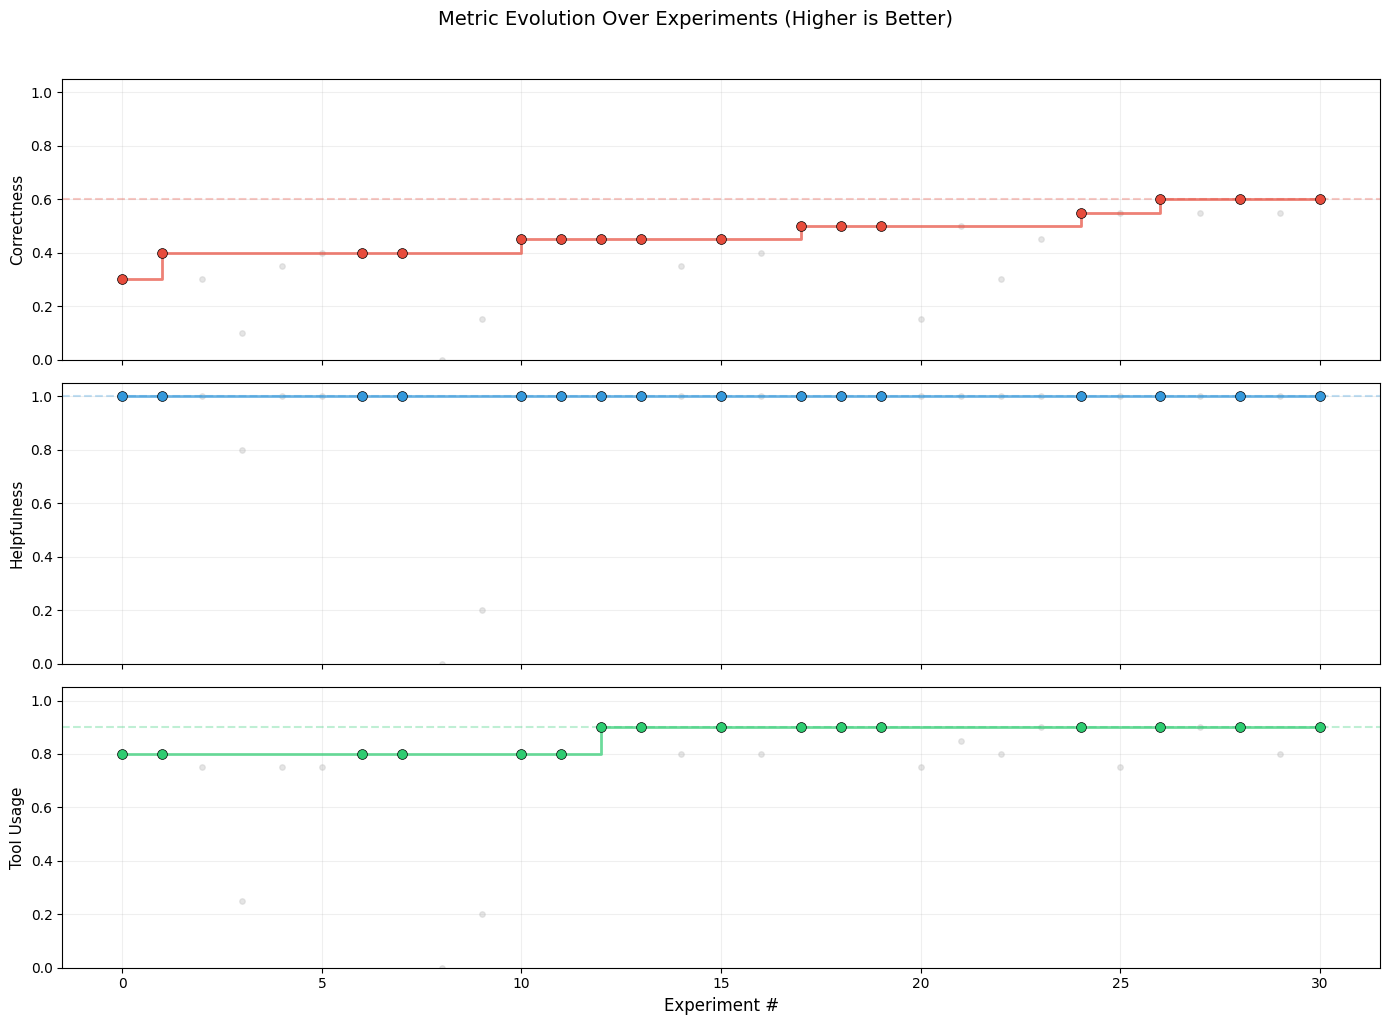

Saved to metrics.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

metrics = ["correctness", "helpfulness", "tool_usage"]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

for ax, metric, color in zip(axes, metrics, colors):
    # Plot all experiments
    ax.scatter(df.index, df[metric], c="#cccccc", s=15, alpha=0.5, zorder=1)
    
    # Highlight kept experiments
    kept_mask = df["status"] == "KEEP"
    ax.scatter(df.index[kept_mask], df[metric][kept_mask], 
               c=color, s=50, zorder=3, edgecolors="black", linewidths=0.5)
    
    # Running maximum for kept experiments
    kept_metric = df.loc[kept_mask, metric]
    running_max = kept_metric.cummax()
    ax.step(df.index[kept_mask], running_max, where="post", 
            color=color, linewidth=2, alpha=0.7, zorder=2)
    
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.2)
    
    # Show final value
    final_val = df[metric].iloc[-1]
    ax.axhline(y=final_val, color=color, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Experiment #", fontsize=12)
fig.suptitle("Metric Evolution Over Experiments (Higher is Better)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to metrics.png")

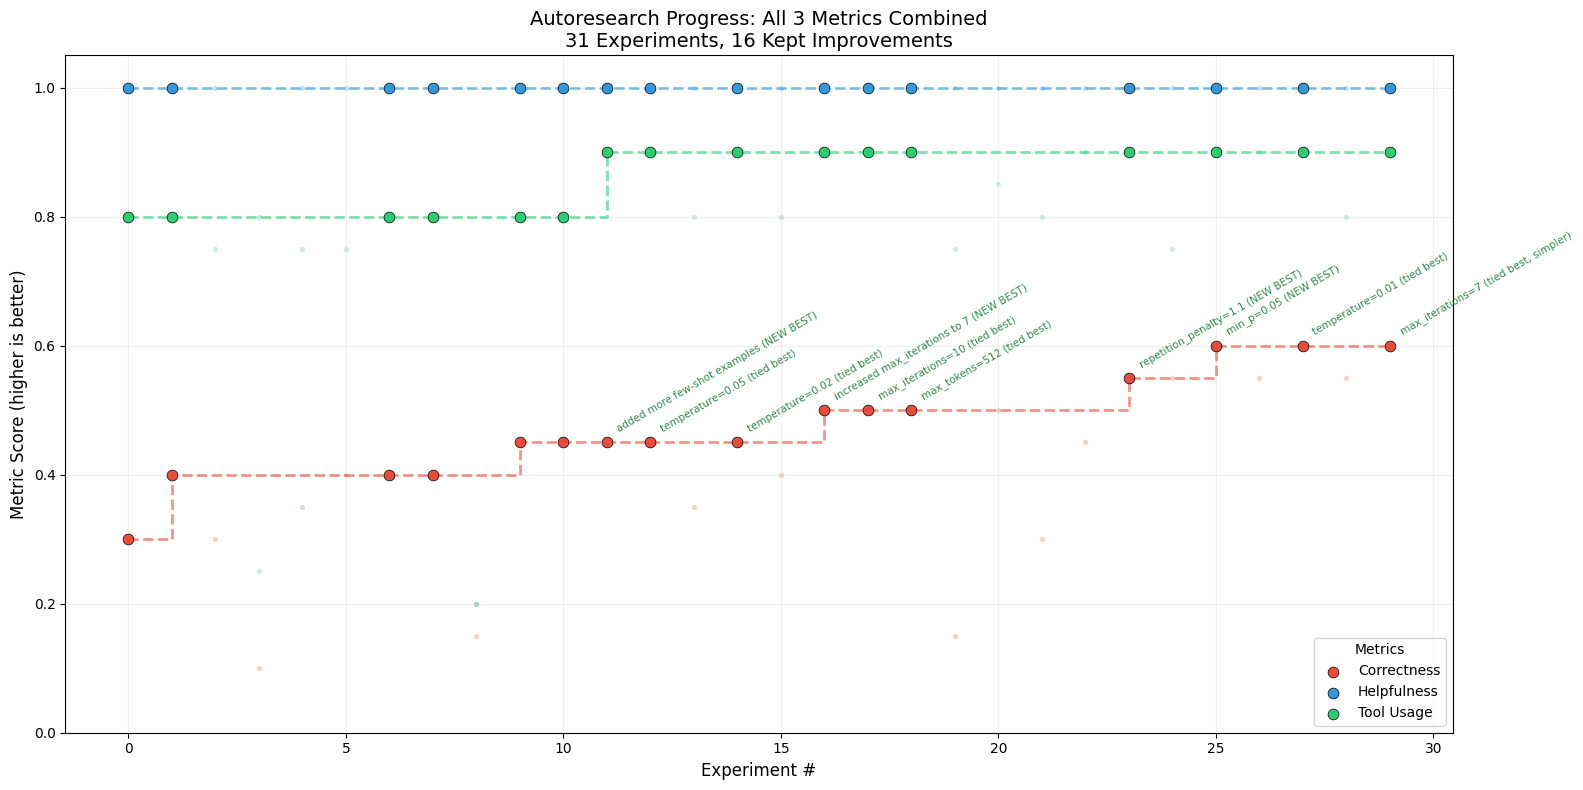

Saved to combined_metrics.png


In [15]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

# Define colors for each metric
metric_colors = {
    "correctness": "#e74c3c",  # Red
    "helpfulness": "#3498db",  # Blue  
    "tool_usage": "#2ecc71"    # Green
}

# Plot all experiments as faint background dots for each metric
for metric, color in metric_colors.items():
    ax.scatter(valid.index, valid[metric], c=color, s=8, alpha=0.2, zorder=1)

# Plot kept experiments with larger markers and black edges
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]

for metric, color in metric_colors.items():
    ax.scatter(kept_idx, valid.loc[kept_mask, metric], 
               c=color, s=60, zorder=4, edgecolors="black", linewidths=0.5, label=metric.replace("_", " ").title())

# Running maximum step lines for each metric
for metric, color in metric_colors.items():
    kept_metric = valid.loc[kept_mask, metric]
    running_max = kept_metric.cummax()
    ax.step(kept_idx, running_max, where="post", color=color,
            linewidth=2, alpha=0.6, zorder=3, linestyle="--")

# Annotate key kept experiments with overall_score
kept_score = valid.loc[kept_mask, "overall_score"]
for idx, score in zip(kept_idx, kept_score):
    if score >= kept_score.max() - 0.05:  # Only annotate best experiments
        desc = str(valid.loc[idx, "description"]).strip()
        if len(desc) > 40:
            desc = desc[:37] + "..."
        ax.annotate(desc, (idx, valid.loc[idx, "correctness"]),
                    textcoords="offset points",
                    xytext=(6, 6), fontsize=7.5,
                    color="#1a7a3a", alpha=0.9,
                    rotation=30, ha="left", va="bottom")

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Metric Score (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: All 3 Metrics Combined\n{len(df)} Experiments, {len(df[df['status']=='KEEP'])} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=10, title="Metrics")
ax.grid(True, alpha=0.2)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("combined_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to combined_metrics.png")